<a href="https://colab.research.google.com/github/moeenessa31-lgtm/Final-Project/blob/main/Fork_of_Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
mlg_ulb_creditcardfraud_path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')

print('Data source import complete.')


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud


In [ ]:
# 1. Load the dataset
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

print(f"Original shape: {df.shape}")
df

Original shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [ ]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]["Class"].value_counts()

Class
0    1062
1      19
Name: count, dtype: int64

In [ ]:
df[df.duplicated()]["Class"].value_counts().sum()

np.int64(1081)

In [ ]:
# 3. Remove duplicate rows
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_rows - len(df)} duplicate rows.")

Removed 1081 duplicate rows.


In [ ]:
# 4. Separate features and target (target 'Class' is used only for evaluation later)
X = df.drop('Class', axis=1)      # Target: 0 = genuine, 1 = fraud
y = df['Class']

In [ ]:
# Scale all features using RobustScaler to reduce the effect of outliers
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.995290,-0.618360,-0.097622,1.229434,0.880878,-0.218773,0.632648,0.176974,0.143677,0.335739,...,0.910319,0.026861,0.253199,-0.320939,0.032627,0.168017,-0.241512,0.816068,-0.246698,1.774718
1,-0.995290,0.524849,0.144367,-0.007034,0.295891,0.087159,0.165383,-0.106558,0.118241,-0.163546,...,-0.019525,-0.473668,-0.602596,0.363373,-0.479559,0.225835,0.314036,-0.064639,0.026214,-0.268530
2,-0.995279,-0.617709,-1.002505,0.831270,0.252882,-0.345402,1.780431,0.668400,0.422384,-1.178892,...,1.704013,0.669336,0.714327,2.974843,-0.919547,-0.514733,-0.153300,-0.351138,-0.541896,4.959811
3,-0.995279,-0.442046,-0.177906,0.841592,-0.529031,0.033147,1.305834,0.175202,0.665139,-1.075980,...,-0.422670,-0.190254,-0.001308,-0.578965,-1.531860,0.944541,-0.299382,0.378404,0.382702,1.411487
4,-0.995267,-0.528050,0.581026,0.714142,0.267510,-0.271669,0.318307,0.491620,-0.547078,0.701771,...,1.366197,0.048275,0.739164,-0.408139,0.126231,-0.332690,0.977848,1.346586,1.555108,0.667362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283721,1.035258,-5.332169,7.145374,-5.225152,-1.285968,-4.078964,-2.000020,-4.415983,13.625815,1.586057,...,4.462686,0.585997,0.098221,3.314371,-0.692986,2.126054,0.532968,5.821307,6.197405,-0.295230
283722,1.035270,-0.337440,-0.084985,0.967874,-0.450591,0.707883,1.143898,-0.014720,0.510672,0.513947,...,0.353866,0.587809,0.856915,0.076334,-1.331217,-0.932275,-0.605059,0.413928,-0.494416,0.038798
283723,1.035282,0.850880,-0.260747,-1.789381,-0.336889,2.061355,2.836132,-0.300704,1.284337,0.391107,...,0.184954,0.630848,0.533691,-0.085126,0.754375,0.373368,-0.062077,0.018389,-0.288712,0.638020
283724,1.035282,-0.116856,0.333095,0.272637,0.447890,-0.249218,0.771022,-0.647418,1.229575,0.358558,...,0.550624,0.710945,0.740817,-0.491641,0.103488,-0.876203,1.056109,0.663224,0.711284,-0.166875


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
print(explained_variance, '\n')
print(cumulative_variance)

[0.2329084  0.10485025 0.09930011 0.08146717 0.07327136 0.06591683
 0.05016271 0.02213296 0.02125077 0.01972987 0.01927324 0.01803447
 0.0160049  0.01512742 0.0136711  0.01325415 0.01313724 0.01297014
 0.01293865 0.01271541 0.01203901 0.01155983 0.0102146  0.00970295
 0.00963621 0.00932302 0.00802073 0.00768465 0.00214503 0.0015568 ] 

[0.2329084  0.33775865 0.43705876 0.51852593 0.59179729 0.65771412
 0.70787683 0.73000979 0.75126056 0.77099043 0.79026367 0.80829814
 0.82430304 0.83943045 0.85310156 0.86635571 0.87949295 0.89246309
 0.90540174 0.91811716 0.93015617 0.941716   0.9519306  0.96163356
 0.97126976 0.98059278 0.98861352 0.99629817 0.9984432  1.        ]


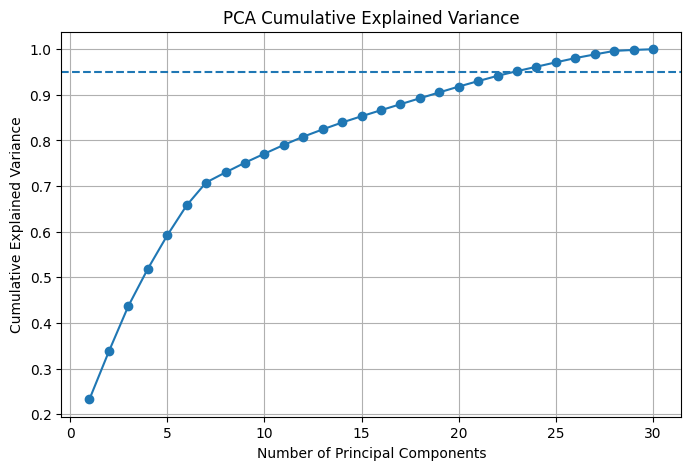

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.95, linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [ ]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_95

np.int64(23)

In [ ]:
pca_95 = PCA(n_components=n_components_95)

X_pca_95 = pca_95.fit_transform(X_scaled)
X_pca_95 = pd.DataFrame(
    X_pca_95,
    columns=[f"PC{i+1}" for i in range(n_components_95)]
)
X_pca_95

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23
0,1.077014,-0.372959,0.706665,0.415740,0.209937,-0.427759,-0.092344,0.390250,0.163230,0.146854,...,0.084403,0.618606,1.230453,-0.200735,-0.526858,0.695692,0.865774,-0.614697,0.553021,-0.361407
1,-1.285498,0.129479,-0.001307,0.111362,0.241415,0.113455,-0.489775,0.082494,-0.033043,-0.182195,...,0.242545,0.225775,0.569366,-0.328982,0.031524,-0.636885,0.911633,0.103961,0.162033,0.352875
2,4.303859,-0.373114,-0.601030,1.023019,1.149025,3.039980,0.142732,0.876007,0.860218,0.276443,...,1.492596,0.949223,-1.251070,-2.412645,-2.761959,0.455985,1.026058,-0.549411,0.293762,-0.754987
3,0.390171,0.347538,0.509091,0.427246,-1.103184,-0.191134,-0.434502,0.807700,0.600307,-0.047278,...,-0.613545,0.595101,-1.244652,-0.809200,-1.495487,0.121412,0.771766,-0.397831,2.331862,0.471771
4,0.153759,1.228655,1.708687,-0.057176,1.085090,-0.951241,0.161061,0.538576,-0.389751,0.819902,...,-0.070452,0.154096,1.188313,0.044209,-0.237449,1.197905,0.871061,0.654348,0.221392,-0.557950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283721,-2.078779,4.489029,7.483372,14.472256,1.702660,1.868218,0.592587,2.046369,-2.383965,5.595274,...,3.560544,3.394864,-4.348819,2.991003,3.831234,3.145502,-3.170931,1.165790,-1.497391,3.842348
283722,-0.799208,-0.508133,0.291210,0.603630,0.098358,-0.041448,0.552892,0.562354,0.554478,-1.236470,...,0.234856,0.249843,-0.923561,-1.621448,-0.056761,0.452437,0.770113,-0.954683,-0.869211,-1.252925
283723,-0.349099,-0.204473,-0.035105,1.259093,-0.475890,0.031131,0.496532,1.424089,2.147087,-1.153439,...,0.320693,-0.382213,-0.749105,-0.463650,0.583325,-0.450901,-1.280184,0.145270,-0.115667,1.164275
283724,-0.992420,0.588211,0.862355,1.329646,-0.100736,-0.625577,0.715226,0.486482,0.430690,-0.353310,...,0.172405,-1.045225,1.703925,2.116057,-0.617156,1.171026,-1.337435,1.109422,0.690429,-0.932781


In [ ]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])
pca_df["Class"] = y.values
pca_df

,PC1,PC2,Class
0,1.077014,-0.372959,0
1,-1.285498,0.129479,0
2,4.303859,-0.373114,0
3,0.390171,0.347538,0
4,0.153759,1.228655,0
...,...,...,...
283721,-2.078779,4.489029,0
283722,-0.799208,-0.508133,0
283723,-0.349099,-0.204473,0
283724,-0.992420,0.588211,0


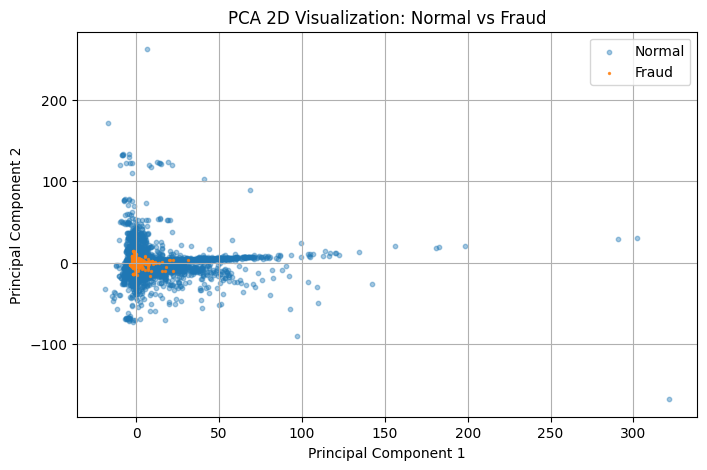

In [ ]:
normal_pca_2 = pca_df[pca_df["Class"] == 0]
fraud_pca_2 = pca_df[pca_df["Class"] == 1]

plt.figure(figsize=(8, 5))
plt.scatter(
    normal_pca_2["PC1"],
    normal_pca_2["PC2"],
    alpha=0.4,
    label="Normal",
    s=10
)
plt.scatter(
    fraud_pca_2["PC1"],
    fraud_pca_2["PC2"],
    alpha=0.8,
    label="Fraud",
    s=2
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Visualization: Normal vs Fraud")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Create a clean t-SNE subset without index mismatch problems

# Combine PCA features with Class
pca_with_class = X_pca_95.copy()
pca_with_class["Class"] = y.values

# Take all fraud transactions + 10,000 normal transactions
fraud_data = pca_with_class[pca_with_class["Class"] == 1]

normal_data = pca_with_class[pca_with_class["Class"] == 0].sample(
    n=10000,
    random_state=42
)

# Combine normal sample with all fraud data
tsne_subset = pd.concat([normal_data, fraud_data], axis=0)

# Shuffle rows
tsne_subset = tsne_subset.sample(frac=1, random_state=42)

# Split features and labels
X_tsne_subset = tsne_subset.drop("Class", axis=1)
y_tsne_subset = tsne_subset["Class"]

print("t-SNE subset shape:", X_tsne_subset.shape)
print("Class distribution:")
print(y_tsne_subset.value_counts())

t-SNE subset shape: (10473, 23)
Class distribution:
Class
0    10000
1      473
Name: count, dtype: int64


In [ ]:
from sklearn.manifold import TSNE
import time

start_time = time.time()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42,
    verbose=1
)

X_tsne = tsne.fit_transform(X_tsne_subset)

end_time = time.time()

print("t-SNE output shape:", X_tsne.shape)
print("Time taken in minutes:", (end_time - start_time) / 60)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10473 samples in 0.001s...
[t-SNE] Computed neighbors for 10473 samples in 0.592s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10473
[t-SNE] Computed conditional probabilities for sample 2000 / 10473
[t-SNE] Computed conditional probabilities for sample 3000 / 10473
[t-SNE] Computed conditional probabilities for sample 4000 / 10473
[t-SNE] Computed conditional probabilities for sample 5000 / 10473
[t-SNE] Computed conditional probabilities for sample 6000 / 10473
[t-SNE] Computed conditional probabilities for sample 7000 / 10473
[t-SNE] Computed conditional probabilities for sample 8000 / 10473
[t-SNE] Computed conditional probabilities for sample 9000 / 10473
[t-SNE] Computed conditional probabilities for sample 10000 / 10473
[t-SNE] Computed conditional probabilities for sample 10473 / 10473
[t-SNE] Mean sigma: 1.011736
[t-SNE] KL divergence after 250 iterations with early exaggeration: 86.038597
[t-SNE] KL 

In [ ]:
# Create a DataFrame for visualization
tsne_df = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])

# Add labels only for coloring and interpretation
tsne_df["Class"] = y_tsne_subset.values

print("t-SNE DataFrame shape:", tsne_df.shape)
print("Class distribution:")
print(tsne_df["Class"].value_counts())

tsne_df.head()

t-SNE DataFrame shape: (10473, 3)
Class distribution:
Class
0    10000
1      473
Name: count, dtype: int64


,TSNE1,TSNE2,Class
0,14.136815,-10.509128,0
1,3.823856,58.333897,0
2,44.030529,-0.717427,0
3,-18.446814,-27.643679,0
4,-7.318778,78.793251,0


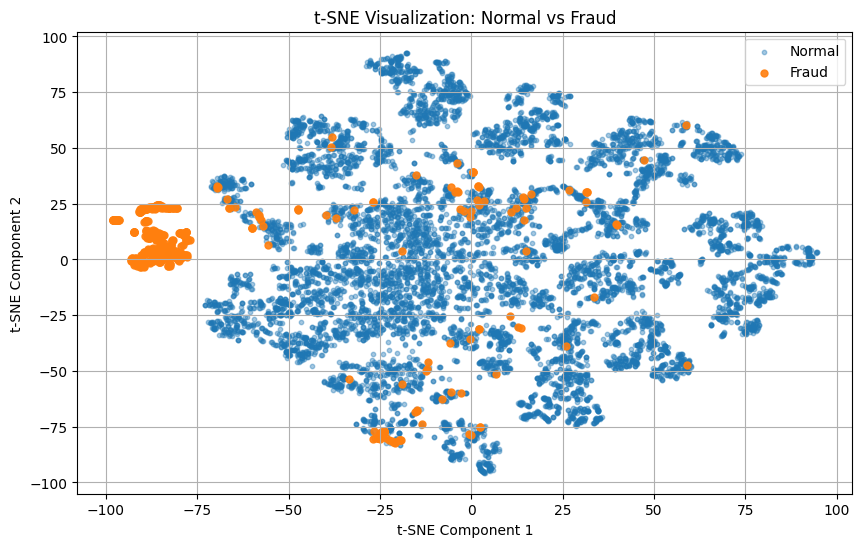

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    tsne_df[tsne_df["Class"] == 0]["TSNE1"],
    tsne_df[tsne_df["Class"] == 0]["TSNE2"],
    alpha=0.4,
    s=10,
    label="Normal"
)

plt.scatter(
    tsne_df[tsne_df["Class"] == 1]["TSNE1"],
    tsne_df[tsne_df["Class"] == 1]["TSNE2"],
    alpha=0.9,
    s=25,
    label="Fraud"
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization: Normal vs Fraud")
plt.legend()
plt.grid(True)
plt.show()

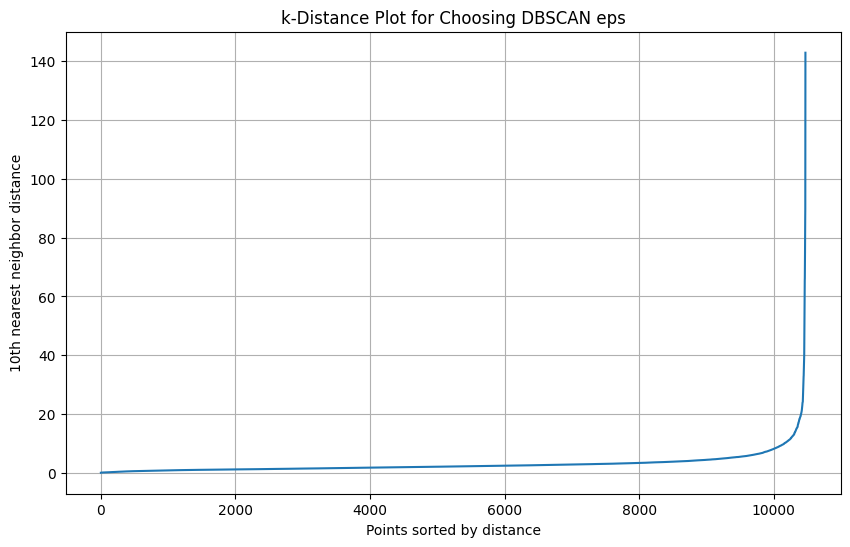

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_tsne_subset)

distances, indices = neighbors_fit.kneighbors(X_tsne_subset)

k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}th nearest neighbor distance")
plt.title("k-Distance Plot for Choosing DBSCAN eps")
plt.grid(True)
plt.show()

k-distance percentiles:
50% percentile: 2.293179666720004
75% percentile: 3.402740955265011
90% percentile: 5.425840784686856
95% percentile: 7.786403459164798
97% percentile: 10.121734652503594
98% percentile: 12.054069194401052
99% percentile: 16.90938173167934
99.5% percentile: 21.796892880561064
99.9% percentile: 64.7860028023397


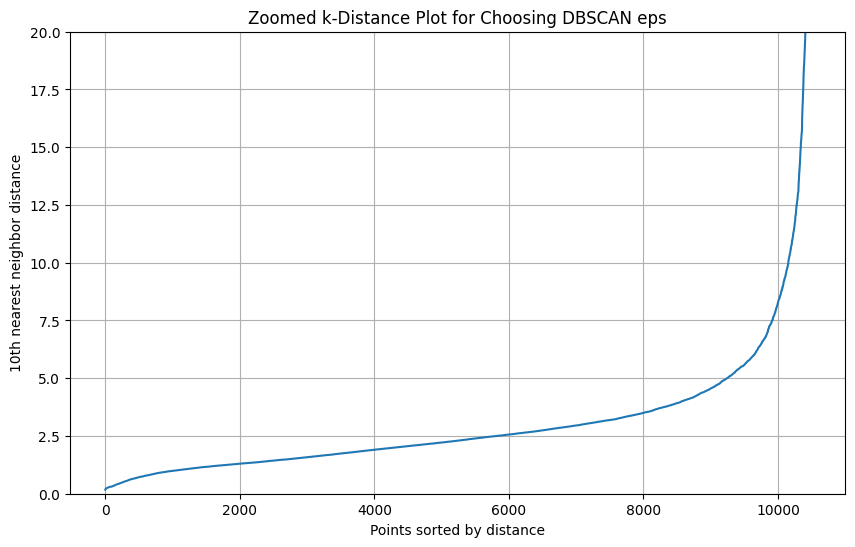

In [ ]:
# Inspect k-distance values more clearly

print("k-distance percentiles:")
for p in [50, 75, 90, 95, 97, 98, 99, 99.5, 99.9]:
    print(f"{p}% percentile:", np.percentile(k_distances, p))

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.ylim(0, 20)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}th nearest neighbor distance")
plt.title("Zoomed k-Distance Plot for Choosing DBSCAN eps")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd

dbscan = DBSCAN(
    eps=8,
    min_samples=10,
    metric="euclidean",
    n_jobs=-1
)

dbscan_labels = dbscan.fit_predict(X_tsne_subset)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = np.sum(dbscan_labels == -1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)
print("Noise percentage:", (n_noise / len(dbscan_labels)) * 100)

print("\nCluster label counts:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

Number of clusters: 3
Number of noise points: 342
Noise percentage: 3.265539959896878

Cluster label counts:
-1      342
 0    10099
 1       22
 2       10
Name: count, dtype: int64


In [ ]:
# Evaluate DBSCAN noise points against the real Class labels

dbscan_results = pd.DataFrame({
    "Actual_Class": y_tsne_subset.values,
    "DBSCAN_Label": dbscan_labels
})

# In DBSCAN, label -1 means noise/anomaly
dbscan_results["Predicted_Anomaly"] = (dbscan_results["DBSCAN_Label"] == -1).astype(int)

print("Cross-tab: Actual Class vs DBSCAN Prediction")
print(pd.crosstab(
    dbscan_results["Actual_Class"],
    dbscan_results["Predicted_Anomaly"],
    rownames=["Actual Class"],
    colnames=["Predicted Anomaly"]
))

print("\nFraud transactions detected as noise:")
fraud_noise = dbscan_results[
    (dbscan_results["Actual_Class"] == 1) &
    (dbscan_results["Predicted_Anomaly"] == 1)
].shape[0]

total_fraud = (dbscan_results["Actual_Class"] == 1).sum()

print(f"{fraud_noise} out of {total_fraud}")
print("Fraud noise detection percentage:", (fraud_noise / total_fraud) * 100)

Cross-tab: Actual Class vs DBSCAN Prediction
Predicted Anomaly     0    1
Actual Class                
0                  9818  182
1                   313  160

Fraud transactions detected as noise:
160 out of 473
Fraud noise detection percentage: 33.82663847780127


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_true = dbscan_results["Actual_Class"]
y_pred = dbscan_results["Predicted_Anomaly"]

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("DBSCAN Performance:")
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Normal", "Fraud"]))

DBSCAN Performance:
Precision: 0.4678362573099415
Recall: 0.3382663847780127
F1-score: 0.39263803680981596

Confusion Matrix:
[[9818  182]
 [ 313  160]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98     10000
       Fraud       0.47      0.34      0.39       473

    accuracy                           0.95     10473
   macro avg       0.72      0.66      0.68     10473
weighted avg       0.95      0.95      0.95     10473



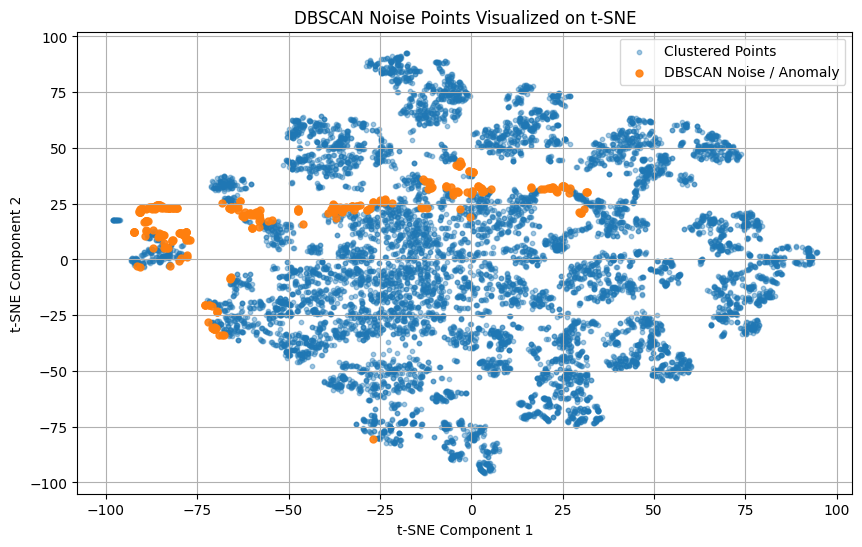

In [ ]:
# Add DBSCAN labels and anomaly prediction to the t-SNE DataFrame
tsne_df["DBSCAN_Label"] = dbscan_labels
tsne_df["DBSCAN_Anomaly"] = (dbscan_labels == -1).astype(int)

plt.figure(figsize=(10, 6))

plt.scatter(
    tsne_df[tsne_df["DBSCAN_Anomaly"] == 0]["TSNE1"],
    tsne_df[tsne_df["DBSCAN_Anomaly"] == 0]["TSNE2"],
    alpha=0.4,
    s=10,
    label="Clustered Points"
)

plt.scatter(
    tsne_df[tsne_df["DBSCAN_Anomaly"] == 1]["TSNE1"],
    tsne_df[tsne_df["DBSCAN_Anomaly"] == 1]["TSNE2"],
    alpha=0.9,
    s=25,
    label="DBSCAN Noise / Anomaly"
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("DBSCAN Noise Points Visualized on t-SNE")
plt.legend()
plt.grid(True)
plt.show()

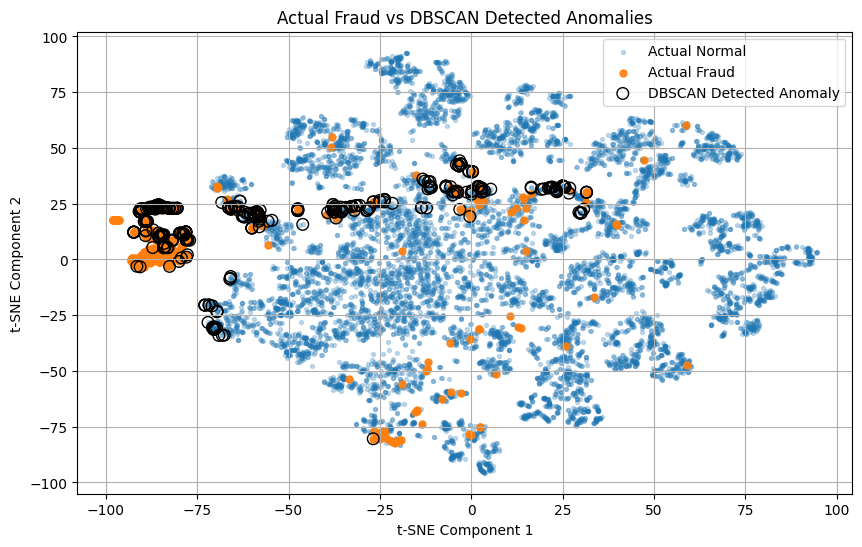

In [ ]:
plt.figure(figsize=(10, 6))

# Normal transactions
plt.scatter(
    tsne_df[tsne_df["Class"] == 0]["TSNE1"],
    tsne_df[tsne_df["Class"] == 0]["TSNE2"],
    alpha=0.25,
    s=8,
    label="Actual Normal"
)

# Actual fraud transactions
plt.scatter(
    tsne_df[tsne_df["Class"] == 1]["TSNE1"],
    tsne_df[tsne_df["Class"] == 1]["TSNE2"],
    alpha=0.9,
    s=25,
    label="Actual Fraud"
)

# DBSCAN anomaly points
plt.scatter(
    tsne_df[tsne_df["DBSCAN_Anomaly"] == 1]["TSNE1"],
    tsne_df[tsne_df["DBSCAN_Anomaly"] == 1]["TSNE2"],
    facecolors="none",
    edgecolors="black",
    s=70,
    label="DBSCAN Detected Anomaly"
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Actual Fraud vs DBSCAN Detected Anomalies")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

eps_values = [5, 6, 7, 8, 9, 10, 12, 15]

results = []

for eps in eps_values:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=10,
        metric="euclidean",
        n_jobs=-1
    )

    labels = dbscan.fit_predict(X_tsne_subset)

    y_true = y_tsne_subset.values
    y_pred = (labels == -1).astype(int)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    noise_percentage = (n_noise / len(labels)) * 100

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    fraud_detected = np.sum((y_true == 1) & (y_pred == 1))

    results.append({
        "eps": eps,
        "min_samples": 10,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "noise_percentage": noise_percentage,
        "fraud_detected": fraud_detected,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

dbscan_eps_results = pd.DataFrame(results)

dbscan_eps_results

,eps,min_samples,clusters,noise_points,noise_percentage,fraud_detected,precision,recall,f1_score
0,5,10,3,888,8.478946,323,0.363739,0.682875,0.474651
1,6,10,3,604,5.767211,247,0.408940,0.522199,0.458682
2,7,10,3,453,4.325408,216,0.476821,0.456660,0.466523
3,8,10,3,342,3.265540,160,0.467836,0.338266,0.392638
4,9,10,3,264,2.520768,123,0.465909,0.260042,0.333786
5,10,10,3,210,2.005156,90,0.428571,0.190275,0.263543
6,12,10,4,133,1.269932,39,0.293233,0.082452,0.128713
7,15,10,2,77,0.735224,26,0.337662,0.054968,0.094545


In [ ]:
best_eps = 5
best_min_samples = 10

best_dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples,
    metric="euclidean",
    n_jobs=-1
)

best_dbscan_labels = best_dbscan.fit_predict(X_tsne_subset)

best_dbscan_results = pd.DataFrame({
    "Actual_Class": y_tsne_subset.values,
    "DBSCAN_Label": best_dbscan_labels
})

best_dbscan_results["Predicted_Anomaly"] = (
    best_dbscan_results["DBSCAN_Label"] == -1
).astype(int)

print("Best DBSCAN so far:")
print("eps:", best_eps)
print("min_samples:", best_min_samples)

print("\nCluster counts:")
print(pd.Series(best_dbscan_labels).value_counts().sort_index())

print("\nConfusion Matrix:")
print(confusion_matrix(
    best_dbscan_results["Actual_Class"],
    best_dbscan_results["Predicted_Anomaly"]
))

print("\nClassification Report:")
print(classification_report(
    best_dbscan_results["Actual_Class"],
    best_dbscan_results["Predicted_Anomaly"],
    target_names=["Normal", "Fraud"]
))

Best DBSCAN so far:
eps: 5
min_samples: 10

Cluster counts:
-1     888
 0    9415
 1      92
 2      78
Name: count, dtype: int64

Confusion Matrix:
[[9435  565]
 [ 150  323]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.94      0.96     10000
       Fraud       0.36      0.68      0.47       473

    accuracy                           0.93     10473
   macro avg       0.67      0.81      0.72     10473
weighted avg       0.96      0.93      0.94     10473



In [ ]:
min_samples_values = [5, 10, 20]
eps_values = [3, 4, 5, 6, 7, 8, 9, 10, 12]

tuning_results = []

for min_s in min_samples_values:
    for eps in eps_values:
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_s,
            metric="euclidean",
            n_jobs=-1
        )

        labels = dbscan.fit_predict(X_tsne_subset)

        y_true = y_tsne_subset.values
        y_pred = (labels == -1).astype(int)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        noise_percentage = (n_noise / len(labels)) * 100

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        fraud_detected = np.sum((y_true == 1) & (y_pred == 1))

        tuning_results.append({
            "eps": eps,
            "min_samples": min_s,
            "clusters": n_clusters,
            "noise_points": n_noise,
            "noise_percentage": noise_percentage,
            "fraud_detected": fraud_detected,
            "precision": precision,
            "recall": recall,
            "f1_score": f1
        })

dbscan_tuning_results = pd.DataFrame(tuning_results)

dbscan_tuning_results.sort_values(
    by="f1_score",
    ascending=False
).head(10)

,eps,min_samples,clusters,noise_points,noise_percentage,fraud_detected,precision,recall,f1_score
21,6,20,2,699,6.674305,292,0.417740,0.617336,0.498294
22,7,20,1,547,5.222954,250,0.457038,0.528541,0.490196
23,8,20,1,422,4.029409,217,0.514218,0.458774,0.484916
20,5,20,3,976,9.319202,350,0.358607,0.739958,0.483092
11,5,10,3,888,8.478946,323,0.363739,0.682875,0.474651
13,7,10,3,453,4.325408,216,0.476821,0.456660,0.466523
12,6,10,3,604,5.767211,247,0.408940,0.522199,0.458682
24,9,20,1,341,3.255992,179,0.524927,0.378436,0.439803
10,4,10,3,1387,13.243579,388,0.279740,0.820296,0.417204
25,10,20,1,290,2.769025,159,0.548276,0.336152,0.416776


In [ ]:
final_eps = 6
final_min_samples = 20

final_dbscan = DBSCAN(
    eps=final_eps,
    min_samples=final_min_samples,
    metric="euclidean",
    n_jobs=-1
)

final_dbscan_labels = final_dbscan.fit_predict(X_tsne_subset)

final_dbscan_results = pd.DataFrame({
    "Actual_Class": y_tsne_subset.values,
    "DBSCAN_Label": final_dbscan_labels
})

final_dbscan_results["Predicted_Anomaly"] = (
    final_dbscan_results["DBSCAN_Label"] == -1
).astype(int)

print("Final Tuned DBSCAN:")
print("eps:", final_eps)
print("min_samples:", final_min_samples)

print("\nCluster counts:")
print(pd.Series(final_dbscan_labels).value_counts().sort_index())

print("\nConfusion Matrix:")
print(confusion_matrix(
    final_dbscan_results["Actual_Class"],
    final_dbscan_results["Predicted_Anomaly"]
))

print("\nClassification Report:")
print(classification_report(
    final_dbscan_results["Actual_Class"],
    final_dbscan_results["Predicted_Anomaly"],
    target_names=["Normal", "Fraud"]
))

Final Tuned DBSCAN:
eps: 6
min_samples: 20

Cluster counts:
-1     699
 0    9671
 1     103
Name: count, dtype: int64

Confusion Matrix:
[[9593  407]
 [ 181  292]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97     10000
       Fraud       0.42      0.62      0.50       473

    accuracy                           0.94     10473
   macro avg       0.70      0.79      0.73     10473
weighted avg       0.96      0.94      0.95     10473



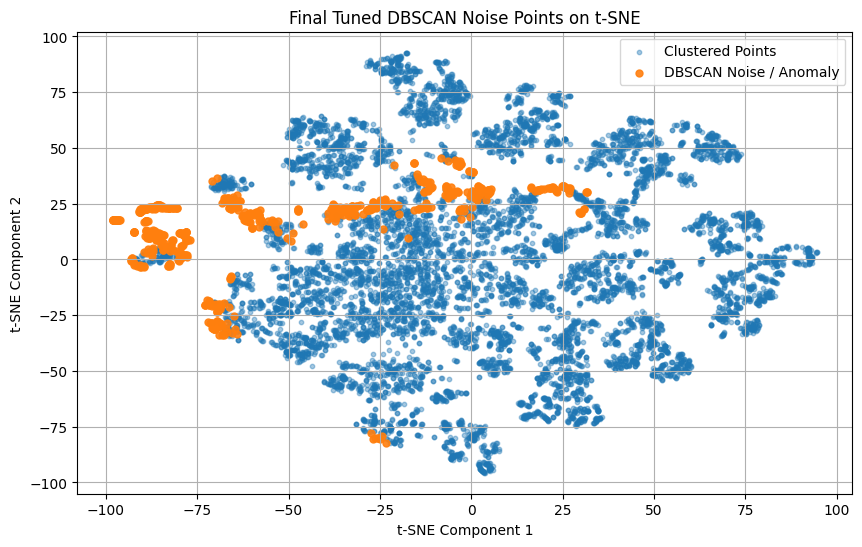

In [ ]:
# Add final DBSCAN labels and anomaly predictions to the t-SNE DataFrame
tsne_df["Final_DBSCAN_Label"] = final_dbscan_labels
tsne_df["Final_DBSCAN_Anomaly"] = (final_dbscan_labels == -1).astype(int)

plt.figure(figsize=(10, 6))

plt.scatter(
    tsne_df[tsne_df["Final_DBSCAN_Anomaly"] == 0]["TSNE1"],
    tsne_df[tsne_df["Final_DBSCAN_Anomaly"] == 0]["TSNE2"],
    alpha=0.4,
    s=10,
    label="Clustered Points"
)

plt.scatter(
    tsne_df[tsne_df["Final_DBSCAN_Anomaly"] == 1]["TSNE1"],
    tsne_df[tsne_df["Final_DBSCAN_Anomaly"] == 1]["TSNE2"],
    alpha=0.9,
    s=25,
    label="DBSCAN Noise / Anomaly"
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Final Tuned DBSCAN Noise Points on t-SNE")
plt.legend()
plt.grid(True)
plt.show()

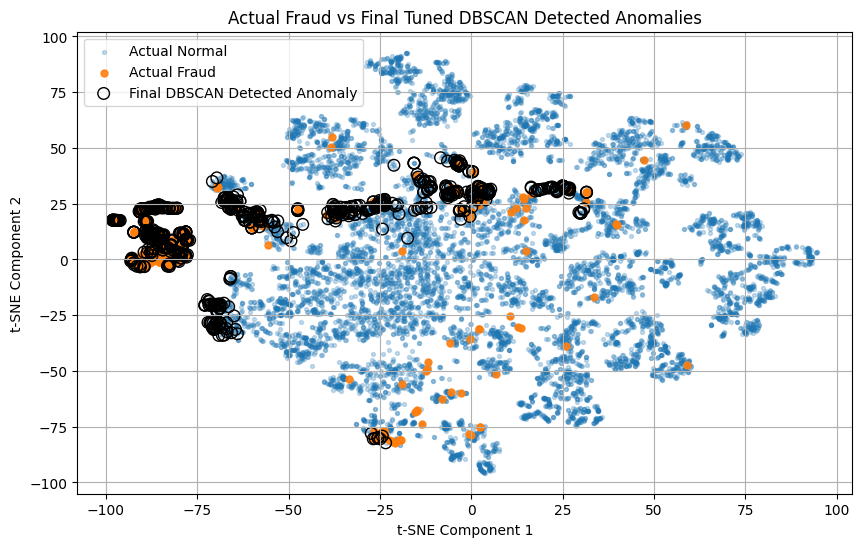

In [ ]:
plt.figure(figsize=(10, 6))

# Actual normal transactions
plt.scatter(
    tsne_df[tsne_df["Class"] == 0]["TSNE1"],
    tsne_df[tsne_df["Class"] == 0]["TSNE2"],
    alpha=0.25,
    s=8,
    label="Actual Normal"
)

# Actual fraud transactions
plt.scatter(
    tsne_df[tsne_df["Class"] == 1]["TSNE1"],
    tsne_df[tsne_df["Class"] == 1]["TSNE2"],
    alpha=0.9,
    s=25,
    label="Actual Fraud"
)

# Final DBSCAN detected anomalies
plt.scatter(
    tsne_df[tsne_df["Final_DBSCAN_Anomaly"] == 1]["TSNE1"],
    tsne_df[tsne_df["Final_DBSCAN_Anomaly"] == 1]["TSNE2"],
    facecolors="none",
    edgecolors="black",
    s=70,
    label="Final DBSCAN Detected Anomaly"
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Actual Fraud vs Final Tuned DBSCAN Detected Anomalies")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Use the PCA-reduced full cleaned dataset
X_ocsvm = X_pca_95.copy()
y_ocsvm = y.reset_index(drop=True)

# Make sure labels are aligned by row order
X_ocsvm = X_ocsvm.reset_index(drop=True)

# Split data while preserving fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_ocsvm,
    y_ocsvm,
    test_size=0.2,
    random_state=42,
    stratify=y_ocsvm
)

# Train One-Class SVM only on normal transactions
X_train_normal = X_train[y_train == 0]

print("Full data shape:", X_ocsvm.shape)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Normal training data shape:", X_train_normal.shape)

print("\nTrain class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Full data shape: (283726, 23)
Training set shape: (226980, 23)
Test set shape: (56746, 23)
Normal training data shape: (226602, 23)

Train class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [ ]:
# One-Class SVM can be slow on very large datasets,
# so we train it on a representative subset of normal transactions.

X_train_normal_sample = X_train_normal.sample(
    n=20000,
    random_state=42
)

print("Normal training sample shape:", X_train_normal_sample.shape)

Normal training sample shape: (20000, 23)


In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import time

start_time = time.time()

ocsvm = OneClassSVM(
    kernel="rbf",
    nu=0.01,
    gamma="scale"
)

ocsvm.fit(X_train_normal_sample)

end_time = time.time()

print("Training time in minutes:", (end_time - start_time) / 60)

Training time in minutes: 0.011414587497711182


In [ ]:
# Predict on the full test set
ocsvm_pred_raw = ocsvm.predict(X_test)

# OneClassSVM returns:
#  1  = normal
# -1  = anomaly
# Convert it to our fraud/anomaly format:
# 0 = normal
# 1 = anomaly/fraud
ocsvm_pred = np.where(ocsvm_pred_raw == -1, 1, 0)

print("Raw prediction counts:")
print(pd.Series(ocsvm_pred_raw).value_counts())

print("\nConverted prediction counts:")
print(pd.Series(ocsvm_pred).value_counts())

Raw prediction counts:
 1    55101
-1     1645
Name: count, dtype: int64

Converted prediction counts:
0    55101
1     1645
Name: count, dtype: int64


In [ ]:
# Evaluate One-Class SVM performance

print("One-Class SVM Performance")
print("Precision:", precision_score(y_test, ocsvm_pred))
print("Recall:", recall_score(y_test, ocsvm_pred))
print("F1-score:", f1_score(y_test, ocsvm_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, ocsvm_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    ocsvm_pred,
    target_names=["Normal", "Fraud"]
))

One-Class SVM Performance
Precision: 0.04680851063829787
Recall: 0.8105263157894737
F1-score: 0.08850574712643679

Confusion Matrix:
[[55083  1568]
 [   18    77]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56651
       Fraud       0.05      0.81      0.09        95

    accuracy                           0.97     56746
   macro avg       0.52      0.89      0.54     56746
weighted avg       1.00      0.97      0.98     56746



In [ ]:
nu_values = [0.001, 0.003, 0.005, 0.01, 0.02, 0.05]

ocsvm_tuning_results = []

for nu in nu_values:
    model = OneClassSVM(
        kernel="rbf",
        nu=nu,
        gamma="scale"
    )

    model.fit(X_train_normal_sample)

    pred_raw = model.predict(X_test)
    pred = np.where(pred_raw == -1, 1, 0)

    precision = precision_score(y_test, pred, zero_division=0)
    recall = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    anomaly_count = np.sum(pred == 1)
    fraud_detected = np.sum((y_test.values == 1) & (pred == 1))

    ocsvm_tuning_results.append({
        "nu": nu,
        "anomaly_count": anomaly_count,
        "fraud_detected": fraud_detected,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

ocsvm_tuning_results = pd.DataFrame(ocsvm_tuning_results)

ocsvm_tuning_results

,nu,anomaly_count,fraud_detected,precision,recall,f1_score
0,0.001,1645,77,0.046809,0.810526,0.088506
1,0.003,1645,77,0.046809,0.810526,0.088506
2,0.005,1644,77,0.046837,0.810526,0.088557
3,0.010,1645,77,0.046809,0.810526,0.088506
4,0.020,1734,77,0.044406,0.810526,0.084199
5,0.050,3012,79,0.026228,0.831579,0.050853


In [ ]:
gamma_values = ["scale", 0.001, 0.005, 0.01, 0.05, 0.1]

best_nu = 0.005

ocsvm_gamma_results = []

for gamma in gamma_values:
    model = OneClassSVM(
        kernel="rbf",
        nu=best_nu,
        gamma=gamma
    )

    model.fit(X_train_normal_sample)

    pred_raw = model.predict(X_test)
    pred = np.where(pred_raw == -1, 1, 0)

    precision = precision_score(y_test, pred, zero_division=0)
    recall = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    anomaly_count = np.sum(pred == 1)
    fraud_detected = np.sum((y_test.values == 1) & (pred == 1))

    ocsvm_gamma_results.append({
        "nu": best_nu,
        "gamma": gamma,
        "anomaly_count": anomaly_count,
        "fraud_detected": fraud_detected,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

ocsvm_gamma_results = pd.DataFrame(ocsvm_gamma_results)

ocsvm_gamma_results.sort_values(by="f1_score", ascending=False)

,nu,gamma,anomaly_count,fraud_detected,precision,recall,f1_score
2,0.005,0.005,681,73,0.107195,0.768421,0.188144
1,0.005,0.001,396,32,0.080808,0.336842,0.130346
3,0.005,0.01,1069,75,0.070159,0.789474,0.128866
0,0.005,scale,1644,77,0.046837,0.810526,0.088557
4,0.005,0.05,3839,78,0.020318,0.821053,0.039654
5,0.005,0.1,7734,83,0.010732,0.873684,0.021203


In [ ]:
gamma_values_fine = [0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008]

best_nu = 0.005

ocsvm_gamma_fine_results = []

for gamma in gamma_values_fine:
    model = OneClassSVM(
        kernel="rbf",
        nu=best_nu,
        gamma=gamma
    )

    model.fit(X_train_normal_sample)

    pred_raw = model.predict(X_test)
    pred = np.where(pred_raw == -1, 1, 0)

    precision = precision_score(y_test, pred, zero_division=0)
    recall = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    anomaly_count = np.sum(pred == 1)
    fraud_detected = np.sum((y_test.values == 1) & (pred == 1))

    ocsvm_gamma_fine_results.append({
        "nu": best_nu,
        "gamma": gamma,
        "anomaly_count": anomaly_count,
        "fraud_detected": fraud_detected,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

ocsvm_gamma_fine_results = pd.DataFrame(ocsvm_gamma_fine_results)

ocsvm_gamma_fine_results.sort_values(by="f1_score", ascending=False)

,nu,gamma,anomaly_count,fraud_detected,precision,recall,f1_score
0,0.005,0.002,449,56,0.124722,0.589474,0.205882
2,0.005,0.004,599,70,0.116861,0.736842,0.201729
1,0.005,0.003,522,61,0.116858,0.642105,0.197731
3,0.005,0.005,681,73,0.107195,0.768421,0.188144
4,0.005,0.006,768,75,0.097656,0.789474,0.173812
5,0.005,0.007,837,75,0.089606,0.789474,0.160944
6,0.005,0.008,924,75,0.081169,0.789474,0.147203


In [ ]:
final_ocsvm = OneClassSVM(
    kernel="rbf",
    nu=0.005,
    gamma=0.004
)

final_ocsvm.fit(X_train_normal_sample)

final_ocsvm_pred_raw = final_ocsvm.predict(X_test)

# Convert One-Class SVM output:
#  1  -> normal -> 0
# -1  -> anomaly -> 1
final_ocsvm_pred = np.where(final_ocsvm_pred_raw == -1, 1, 0)

print("Final One-Class SVM:")
print("nu:", 0.005)
print("gamma:", 0.004)

print("\nPrediction counts:")
print(pd.Series(final_ocsvm_pred).value_counts())

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_ocsvm_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    final_ocsvm_pred,
    target_names=["Normal", "Fraud"]
))

Final One-Class SVM:
nu: 0.005
gamma: 0.004

Prediction counts:
0    56147
1      599
Name: count, dtype: int64

Confusion Matrix:
[[56122   529]
 [   25    70]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     56651
       Fraud       0.12      0.74      0.20        95

    accuracy                           0.99     56746
   macro avg       0.56      0.86      0.60     56746
weighted avg       1.00      0.99      0.99     56746



In [ ]:
# Prepare data for Autoencoder

X_train_auto = X_train_normal.values.astype("float32")
X_test_auto = X_test.values.astype("float32")
y_test_auto = y_test.values

print("Autoencoder training data shape:", X_train_auto.shape)
print("Autoencoder test data shape:", X_test_auto.shape)
print("Test labels shape:", y_test_auto.shape)

print("\nTest class distribution:")
print(pd.Series(y_test_auto).value_counts())

Autoencoder training data shape: (226602, 23)
Autoencoder test data shape: (56746, 23)
Test labels shape: (56746,)

Test class distribution:
0    56651
1       95
Name: count, dtype: int64


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

# For reproducibility
tf.random.set_seed(42)
np.random.seed(42)

input_dim = X_train_auto.shape[1]

# Encoder
input_layer = Input(shape=(input_dim,))

encoded = Dense(16, activation="relu")(input_layer)
encoded = Dense(8, activation="relu")(encoded)
latent = Dense(4, activation="relu")(encoded)

# Decoder
decoded = Dense(8, activation="relu")(latent)
decoded = Dense(16, activation="relu")(decoded)
output_layer = Dense(input_dim, activation="linear")(decoded)

# Autoencoder model
autoencoder = Model(inputs=input_layer, outputs=output_layer)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

2026-05-20 20:25:44.021602: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779308744.235907      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779308744.304554      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779308744.835648      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779308744.835686      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779308744.835689      57 computation_placer.cc:177] computation placer alr

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 23)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 23)             │           391 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,131 (4.42 KB)

 Trainable params: 1,131 (4.42 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_auto,
    X_train_auto,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)

Epoch 1/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 2.0097 - val_loss: 1.2233
Epoch 2/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.1679 - val_loss: 1.0521
Epoch 3/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.0470 - val_loss: 0.9806
Epoch 4/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9527 - val_loss: 0.9019
Epoch 5/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8676 - val_loss: 0.8397
Epoch 6/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8023 - val_loss: 0.7927
Epoch 7/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7595 - val_loss: 0.7600
Epoch 8/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7312 - val_loss: 0.7364
Epoch 9/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7111 - val_loss: 0.7186
Epoch 10/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6952 - val_loss: 0.7048
Epoch 11/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6827 - val_loss: 0.6921
Epoch 12/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

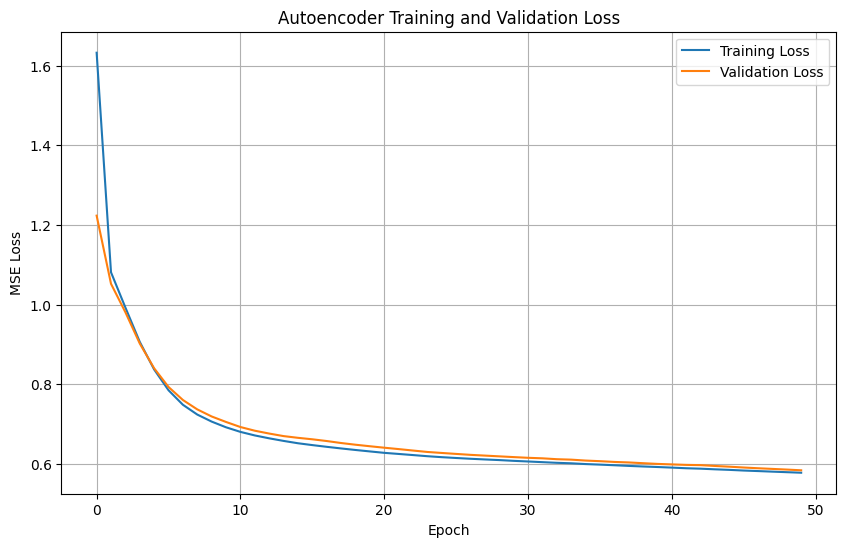

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Reconstruct the test data
X_test_reconstructed = autoencoder.predict(X_test_auto)

# Calculate reconstruction error for each transaction
reconstruction_errors = np.mean(
    np.square(X_test_auto - X_test_reconstructed),
    axis=1
)

# Create a DataFrame for analysis
autoencoder_results = pd.DataFrame({
    "Actual_Class": y_test_auto,
    "Reconstruction_Error": reconstruction_errors
})

autoencoder_results.head()

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


,Actual_Class,Reconstruction_Error
0,0,0.140867
1,0,0.236528
2,0,0.869955
3,0,0.307708
4,0,0.241687


In [ ]:
# Compare reconstruction error statistics for normal and fraud transactions

autoencoder_results.groupby("Actual_Class")["Reconstruction_Error"].describe()

,count,mean,std,min,25%,50%,75%,max
Actual_Class,,,,,,,,
0,56651.0,0.586152,1.84884,0.037062,0.224095,0.370249,0.616361,192.522781
1,95.0,21.109577,29.15987,0.166066,4.684113,8.630989,21.166681,109.492897


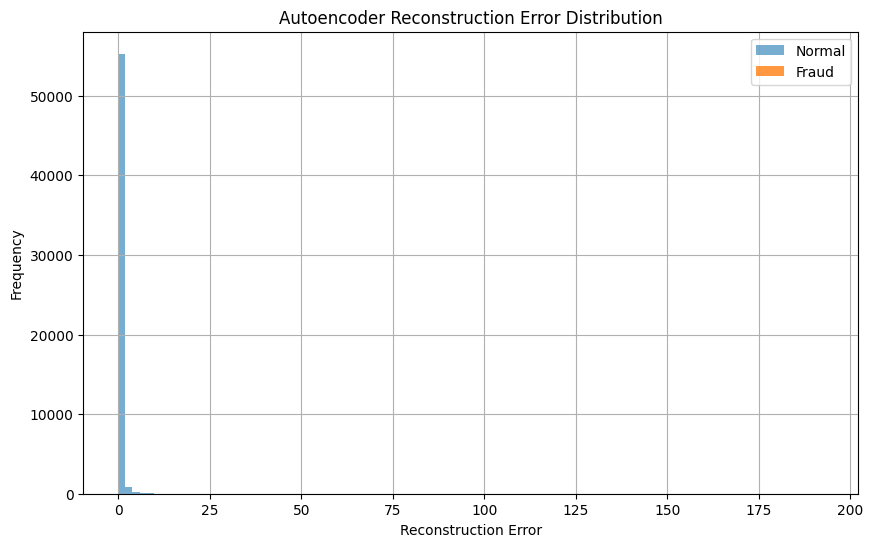

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    autoencoder_results[autoencoder_results["Actual_Class"] == 0]["Reconstruction_Error"],
    bins=100,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    autoencoder_results[autoencoder_results["Actual_Class"] == 1]["Reconstruction_Error"],
    bins=100,
    alpha=0.8,
    label="Fraud"
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Autoencoder Reconstruction Error Distribution")
plt.legend()
plt.grid(True)
plt.show()

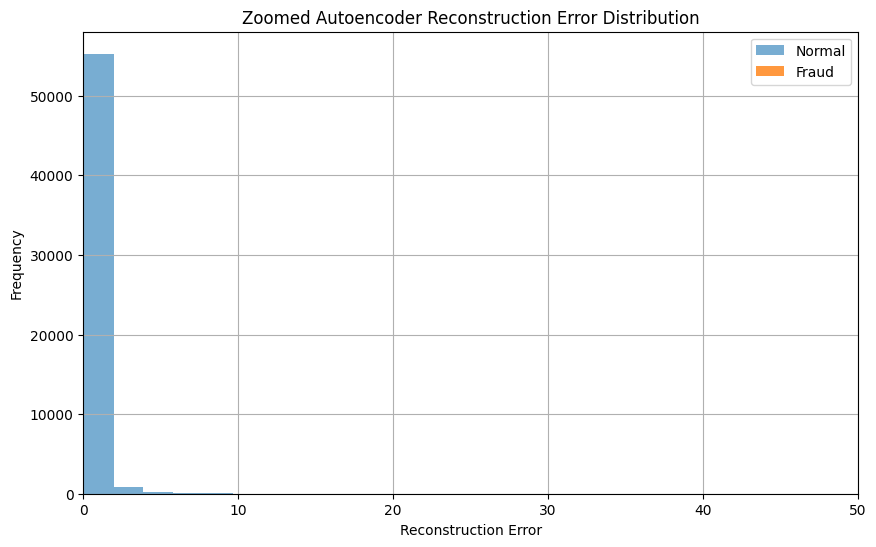

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    autoencoder_results[autoencoder_results["Actual_Class"] == 0]["Reconstruction_Error"],
    bins=100,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    autoencoder_results[autoencoder_results["Actual_Class"] == 1]["Reconstruction_Error"],
    bins=100,
    alpha=0.8,
    label="Fraud"
)

plt.xlim(0, 50)

plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Zoomed Autoencoder Reconstruction Error Distribution")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Reconstruct the normal training data
X_train_reconstructed = autoencoder.predict(X_train_auto)

# Calculate reconstruction error for normal training transactions
train_reconstruction_errors = np.mean(
    np.square(X_train_auto - X_train_reconstructed),
    axis=1
)

# Check possible threshold values from normal training errors
threshold_percentiles = [95, 97, 98, 99, 99.5, 99.7, 99.9]

print("Threshold candidates based on normal training reconstruction errors:")

for p in threshold_percentiles:
    threshold = np.percentile(train_reconstruction_errors, p)
    print(f"{p}% percentile threshold: {threshold}")

7082/7082 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
Threshold candidates based on normal training reconstruction errors:
95% percentile threshold: 1.3567612171173096
97% percentile threshold: 1.7429066896438599
98% percentile threshold: 2.1901841163635254
99% percentile threshold: 3.3915321826934814
99.5% percentile threshold: 5.7474212646484375
99.7% percentile threshold: 8.072371482849121
99.9% percentile threshold: 19.120214462280273


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

threshold_percentiles = [95, 97, 98, 99, 99.5, 99.7, 99.9]

autoencoder_threshold_results = []

for p in threshold_percentiles:
    threshold = np.percentile(train_reconstruction_errors, p)

    # Predict anomaly if reconstruction error is greater than threshold
    y_pred_auto = (autoencoder_results["Reconstruction_Error"] > threshold).astype(int)

    precision = precision_score(y_test_auto, y_pred_auto, zero_division=0)
    recall = recall_score(y_test_auto, y_pred_auto, zero_division=0)
    f1 = f1_score(y_test_auto, y_pred_auto, zero_division=0)

    anomaly_count = np.sum(y_pred_auto == 1)
    fraud_detected = np.sum((y_test_auto == 1) & (y_pred_auto == 1))

    autoencoder_threshold_results.append({
        "percentile": p,
        "threshold": threshold,
        "anomaly_count": anomaly_count,
        "fraud_detected": fraud_detected,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

autoencoder_threshold_results = pd.DataFrame(autoencoder_threshold_results)

autoencoder_threshold_results.sort_values(by="f1_score", ascending=False)

,percentile,threshold,anomaly_count,fraud_detected,precision,recall,f1_score
5,99.7,8.072371,239,49,0.205021,0.515789,0.293413
6,99.9,19.120214,87,25,0.287356,0.263158,0.274725
4,99.5,5.747421,343,58,0.169096,0.610526,0.264840
3,99.0,3.391532,642,74,0.115265,0.778947,0.200814
2,98.0,2.190184,1183,75,0.063398,0.789474,0.117371
1,97.0,1.742907,1790,78,0.043575,0.821053,0.082759
0,95.0,1.356761,2908,80,0.027510,0.842105,0.053280


In [ ]:
final_threshold_percentile = 99.7
final_autoencoder_threshold = np.percentile(
    train_reconstruction_errors,
    final_threshold_percentile
)

final_autoencoder_pred = (
    autoencoder_results["Reconstruction_Error"] > final_autoencoder_threshold
).astype(int)

print("Final Autoencoder Threshold:")
print("Percentile:", final_threshold_percentile)
print("Threshold:", final_autoencoder_threshold)

print("\nPrediction counts:")
print(pd.Series(final_autoencoder_pred).value_counts())

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_auto, final_autoencoder_pred))

print("\nClassification Report:")
print(classification_report(
    y_test_auto,
    final_autoencoder_pred,
    target_names=["Normal", "Fraud"]
))

In [ ]:
# Compare final models

model_comparison = pd.DataFrame([
    {
        "Model": "DBSCAN",
        "Evaluation_Data": "t-SNE subset",
        "Precision": precision_score(
            final_dbscan_results["Actual_Class"],
            final_dbscan_results["Predicted_Anomaly"],
            zero_division=0
        ),
        "Recall": recall_score(
            final_dbscan_results["Actual_Class"],
            final_dbscan_results["Predicted_Anomaly"],
            zero_division=0
        ),
        "F1-score": f1_score(
            final_dbscan_results["Actual_Class"],
            final_dbscan_results["Predicted_Anomaly"],
            zero_division=0
        )
    },
    {
        "Model": "One-Class SVM",
        "Evaluation_Data": "Full test set",
        "Precision": precision_score(y_test, final_ocsvm_pred, zero_division=0),
        "Recall": recall_score(y_test, final_ocsvm_pred, zero_division=0),
        "F1-score": f1_score(y_test, final_ocsvm_pred, zero_division=0)
    },
    {
        "Model": "Autoencoder",
        "Evaluation_Data": "Full test set",
        "Precision": precision_score(y_test_auto, final_autoencoder_pred, zero_division=0),
        "Recall": recall_score(y_test_auto, final_autoencoder_pred, zero_division=0),
        "F1-score": f1_score(y_test_auto, final_autoencoder_pred, zero_division=0)
    }
])

model_comparison

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

# One-Class SVM anomaly scores
# decision_function gives higher scores for normal points
# so we multiply by -1 to make higher score = more anomalous
ocsvm_scores = -final_ocsvm.decision_function(X_test)

# Autoencoder anomaly scores
# higher reconstruction error = more anomalous
autoencoder_scores = autoencoder_results["Reconstruction_Error"].values

auc_comparison = pd.DataFrame([
    {
        "Model": "One-Class SVM",
        "ROC-AUC": roc_auc_score(y_test, ocsvm_scores),
        "PR-AUC": average_precision_score(y_test, ocsvm_scores)
    },
    {
        "Model": "Autoencoder",
        "ROC-AUC": roc_auc_score(y_test_auto, autoencoder_scores),
        "PR-AUC": average_precision_score(y_test_auto, autoencoder_scores)
    }
])

auc_comparison

In [ ]:
from sklearn.metrics import roc_curve, auc

# ROC curves
fpr_ocsvm, tpr_ocsvm, _ = roc_curve(y_test, ocsvm_scores)
roc_auc_ocsvm = auc(fpr_ocsvm, tpr_ocsvm)

fpr_auto, tpr_auto, _ = roc_curve(y_test_auto, autoencoder_scores)
roc_auc_auto = auc(fpr_auto, tpr_auto)

plt.figure(figsize=(10, 6))

plt.plot(fpr_ocsvm, tpr_ocsvm, label=f"One-Class SVM (AUC = {roc_auc_ocsvm:.3f})")
plt.plot(fpr_auto, tpr_auto, label=f"Autoencoder (AUC = {roc_auc_auto:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: One-Class SVM vs Autoencoder")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall curves
precision_ocsvm, recall_ocsvm, _ = precision_recall_curve(y_test, ocsvm_scores)
pr_auc_ocsvm = average_precision_score(y_test, ocsvm_scores)

precision_auto, recall_auto, _ = precision_recall_curve(y_test_auto, autoencoder_scores)
pr_auc_auto = average_precision_score(y_test_auto, autoencoder_scores)

plt.figure(figsize=(10, 6))

plt.plot(recall_ocsvm, precision_ocsvm, label=f"One-Class SVM (PR-AUC = {pr_auc_ocsvm:.3f})")
plt.plot(recall_auto, precision_auto, label=f"Autoencoder (PR-AUC = {pr_auc_auto:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: One-Class SVM vs Autoencoder")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
final_comparison = pd.DataFrame([
    {
        "Model": "DBSCAN",
        "Data Used": "t-SNE subset",
        "Main Parameters": "eps=6, min_samples=20",
        "Precision": precision_score(
            final_dbscan_results["Actual_Class"],
            final_dbscan_results["Predicted_Anomaly"],
            zero_division=0
        ),
        "Recall": recall_score(
            final_dbscan_results["Actual_Class"],
            final_dbscan_results["Predicted_Anomaly"],
            zero_division=0
        ),
        "F1-score": f1_score(
            final_dbscan_results["Actual_Class"],
            final_dbscan_results["Predicted_Anomaly"],
            zero_division=0
        ),
        "ROC-AUC": None,
        "PR-AUC": None
    },
    {
        "Model": "One-Class SVM",
        "Data Used": "Full test set",
        "Main Parameters": "kernel=rbf, nu=0.005, gamma=0.004",
        "Precision": precision_score(y_test, final_ocsvm_pred, zero_division=0),
        "Recall": recall_score(y_test, final_ocsvm_pred, zero_division=0),
        "F1-score": f1_score(y_test, final_ocsvm_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, ocsvm_scores),
        "PR-AUC": average_precision_score(y_test, ocsvm_scores)
    },
    {
        "Model": "Autoencoder",
        "Data Used": "Full test set",
        "Main Parameters": "threshold=99.7 percentile",
        "Precision": precision_score(y_test_auto, final_autoencoder_pred, zero_division=0),
        "Recall": recall_score(y_test_auto, final_autoencoder_pred, zero_division=0),
        "F1-score": f1_score(y_test_auto, final_autoencoder_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_auto, autoencoder_scores),
        "PR-AUC": average_precision_score(y_test_auto, autoencoder_scores)
    }
])

final_comparison

In [ ]:
comparison_plot = final_comparison.copy()

metrics = ["Precision", "Recall", "F1-score"]

comparison_plot.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(title="Metric")
plt.show()

In [ ]:
# Create an encoder model to extract the learned latent representation

encoder = Model(inputs=input_layer, outputs=latent)

X_test_latent = encoder.predict(X_test_auto)

latent_df = pd.DataFrame(
    X_test_latent,
    columns=["Latent_1", "Latent_2", "Latent_3", "Latent_4"]
)

latent_df["Class"] = y_test_auto

print("Latent representation shape:", latent_df.shape)
print("Class distribution:")
print(latent_df["Class"].value_counts())

latent_df.head()

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    latent_df[latent_df["Class"] == 0]["Latent_1"],
    latent_df[latent_df["Class"] == 0]["Latent_2"],
    alpha=0.3,
    s=8,
    label="Normal"
)

plt.scatter(
    latent_df[latent_df["Class"] == 1]["Latent_1"],
    latent_df[latent_df["Class"] == 1]["Latent_2"],
    alpha=0.9,
    s=25,
    label="Fraud"
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Autoencoder Latent Space Visualization")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    latent_df[latent_df["Class"] == 0]["Latent_1"],
    latent_df[latent_df["Class"] == 0]["Latent_2"],
    alpha=0.3,
    s=8,
    label="Normal"
)

plt.scatter(
    latent_df[latent_df["Class"] == 1]["Latent_1"],
    latent_df[latent_df["Class"] == 1]["Latent_2"],
    alpha=0.9,
    s=25,
    label="Fraud"
)

plt.xlim(0, 100)
plt.ylim(0, 150)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Zoomed Autoencoder Latent Space Visualization")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Create a clean rounded final comparison table for reporting

final_comparison_rounded = final_comparison.copy()

numeric_cols = ["Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]

for col in numeric_cols:
    final_comparison_rounded[col] = final_comparison_rounded[col].round(3)

final_comparison_rounded

### Final Model Comparison

The final comparison shows that each model has different strengths.

DBSCAN achieved the highest F1-score in this experiment, with a precision of 0.418, recall of 0.617, and F1-score of 0.498. However, DBSCAN was evaluated on the t-SNE subset rather than the full test set, so its results should be interpreted mainly as an exploratory clustering/anomaly detection result.

One-Class SVM achieved the highest recall on the full test set, with a recall of 0.737. This means it detected the largest proportion of fraud cases among the full-test-set models. However, its precision was low at 0.117, meaning it produced many false positives.

The Autoencoder achieved better precision, F1-score, ROC-AUC, and PR-AUC than One-Class SVM on the full test set. Its ROC-AUC was 0.935 and PR-AUC was 0.191, which indicates that it ranked fraudulent transactions better overall. Although its recall was lower than One-Class SVM, it provided a better overall balance between anomaly scoring and false positives.

Overall, One-Class SVM is useful when the main priority is detecting as many fraud cases as possible, while the Autoencoder is the strongest full-test-set model overall based on ROC-AUC, PR-AUC, and F1-score.

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Exclude DBSCAN noise points because noise label -1 is not a real cluster
clustered_mask = final_dbscan_labels != -1

X_clustered = X_tsne_subset[clustered_mask]
labels_clustered = final_dbscan_labels[clustered_mask]

print("Number of clustered points:", X_clustered.shape[0])
print("Number of noise points:", np.sum(final_dbscan_labels == -1))
print("Number of clusters:", len(set(labels_clustered)))

if len(set(labels_clustered)) > 1:
    silhouette = silhouette_score(X_clustered, labels_clustered)
    davies_bouldin = davies_bouldin_score(X_clustered, labels_clustered)

    print("Silhouette Score:", silhouette)
    print("Davies-Bouldin Index:", davies_bouldin)
else:
    print("Silhouette Score and Davies-Bouldin Index cannot be calculated because there is only one cluster.")